In [69]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve



In [4]:
#Download latest version
kagglehub.login()
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

In [37]:
print("Arquivos no dataset:", os.listdir(path))  #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [38]:
rota = os.path.join(path, 'Teen_Mental_Health_Dataset.csv')

In [39]:
df = pd.read_csv(rota)
df.shape  #linhas + colunas

(1200, 13)

In [40]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# Visão Geral do Dataset

Esse Dataset estuda como o uso de redes sociais afeta a saúde mental de adolescentes. Ele inclui hábitos diários como tempo gasto em redes sociais, sono, estresse, ansiedade e atividade física.

O objetivo é entender se o uso elevado de redes sociais está relacionado a problemas como estresse, ansiedade e depressão. Os dados ajudam na análise de comportamento e na construção de modelos de machine learning para prever riscos à saúde mental.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


- Qual é a força da correlação entre `daily_social_media_hours` e os 4 níveis de impacto (`stress_level`, `anxiety_level`, `addiction_level` e `depression_label`)?
- Como o screen_time_before_sleep atua como um multiplicador negativo na qualidade do sono (`sleep_hours`) e como isso reflete no dia seguinte?
- Adolescentes com maior taxa de `physical_activity` apresentam níveis significativamente menores de estresse ou ansiedade, mesmo mantendo alto uso de redes sociais?
- A plataforma utilizada (`platform_usage`, como TikTok vs Instagram) isola comportamentos específicos? O impacto no `academic_performance` muda de acordo com a rede escolhida?

## PRIMEIRA PERGUNTA
- Qual é a força da correlação entre `daily_social_media_hours` e os 4 níveis de impacto (`stress_level`, `anxiety_level`, `addiction_level` e `depression_label`)?


In [42]:
cols = ['daily_social_media_hours', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
new_df = df[cols]

#vai calcular a matriz de correlação (Correlação de Pearson)
matrix = new_df.corr()

print("Matriz de Correlação:")
print(matrix.to_markdown())

Matriz de Correlação:
|                          |   daily_social_media_hours |   stress_level |   anxiety_level |   addiction_level |   depression_label |
|:-------------------------|---------------------------:|---------------:|----------------:|------------------:|-------------------:|
| daily_social_media_hours |                  1         |    0.0306977   |       0.0278348 |      -0.0249641   |          0.175201  |
| stress_level             |                  0.0306977 |    1           |       0.0158113 |      -0.000129395 |          0.170474  |
| anxiety_level            |                  0.0278348 |    0.0158113   |       1         |       0.0311538   |          0.169566  |
| addiction_level          |                 -0.0249641 |   -0.000129395 |       0.0311538 |       1           |         -0.0139521 |
| depression_label         |                  0.175201  |    0.170474    |       0.169566  |      -0.0139521   |          1         |


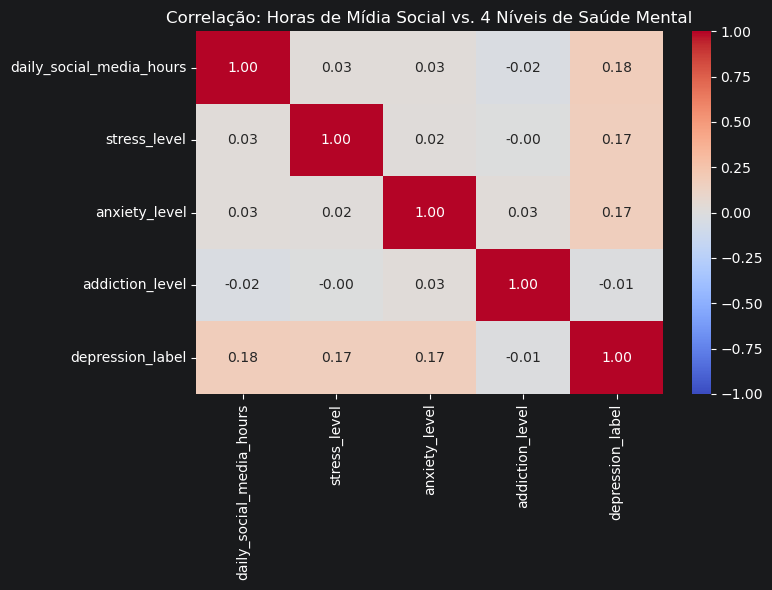

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,  # Mostra os valores numéricos em cada célula
    cmap='coolwarm',  # Esquema de cores: azul para negativo, vermelho para positivo
    vmin=-1, vmax=1,  # Fixa a escala de -1 a 1 para precisão visual
    fmt=".2f"  # Formata as casas decimais
)
plt.title('Correlação: Horas de Mídia Social vs. 4 Níveis de Saúde Mental')
plt.tight_layout()
plt.show()

Apesar da correlação ser fraca, verificamos que `depression_label` é a única que teve uma correlação maior com as horas diárias

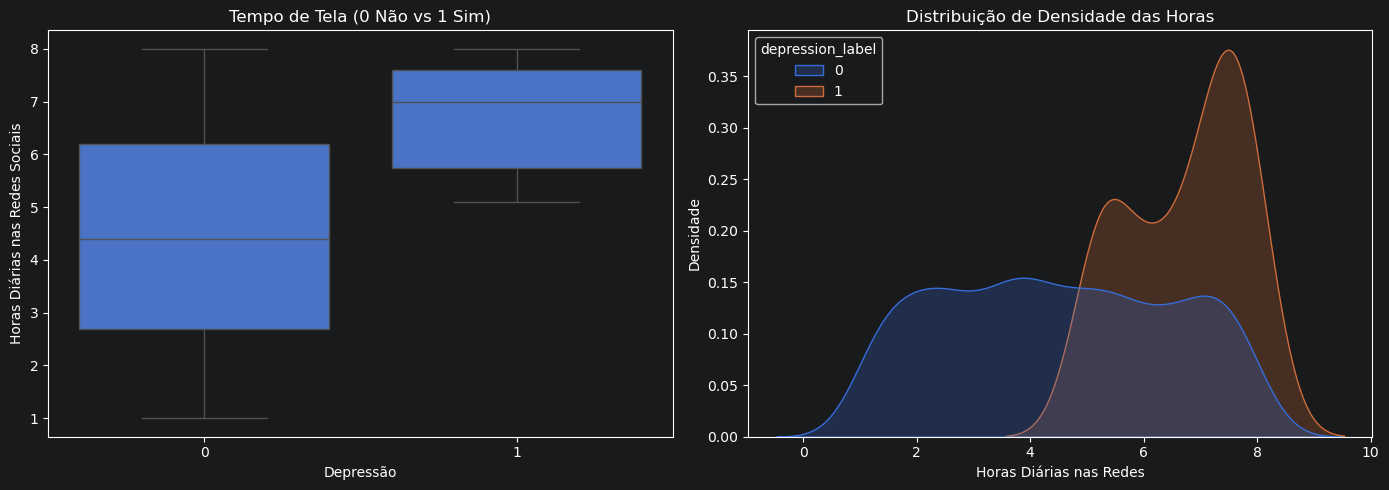

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, ax=axes[0])
axes[0].set(title='Tempo de Tela (0 Não vs 1 Sim)', xlabel='Depressão', ylabel='Horas Diárias nas Redes Sociais')

sns.kdeplot(data=df, x='daily_social_media_hours', hue='depression_label', common_norm=False, fill=True, ax=axes[1])
axes[1].set(title='Distribuição de Densidade das Horas', xlabel='Horas Diárias nas Redes', ylabel='Densidade')

plt.tight_layout()
plt.show()

## SEGUNDA PERGUNTA
- Como o screen_time_before_sleep atua como um multiplicador negativo na qualidade do sono (`sleep_hours`) e como isso reflete no dia seguinte?


In [45]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [46]:
# 1. Calculando correlações chaves
corl_sleep = df['screen_time_before_sleep'].corr(df['sleep_hours'])
corl_academic = df['screen_time_before_sleep'].corr(df['academic_performance'])
corl_stress = df['screen_time_before_sleep'].corr(df['stress_level'])
corl_activ = df['screen_time_before_sleep'].corr(df['physical_activity'])

print(f"Correlação Tela antes de dormir vs Horas de Sono: {corl_sleep:.2f}")
print(f"Correlação Tela antes de dormir vs Performance Acadêmica: {corl_academic:.2f}")
print(f"Correlação Tela antes de dormir vs Estresse: {corl_stress:.2f}")
print(f"Correlação Tela antes de dormir vs Atividade Física: {corl_activ:.2f}")

Correlação Tela antes de dormir vs Horas de Sono: 0.01
Correlação Tela antes de dormir vs Performance Acadêmica: -0.03
Correlação Tela antes de dormir vs Estresse: -0.01
Correlação Tela antes de dormir vs Atividade Física: -0.03


/var/folders/_m/wq3xqkf168j77qn4m4_tntxr0000gn/T/ipykernel_84223/2437457966.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='screen_time_cat', y='academic_performance', data=df, palette='mako', ax=axes[1])
/var/folders/_m/wq3xqkf168j77qn4m4_tntxr0000gn/T/ipykernel_84223/2437457966.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='screen_time_cat', y='stress_level', data=df, palette='flare', ax=axes[2])


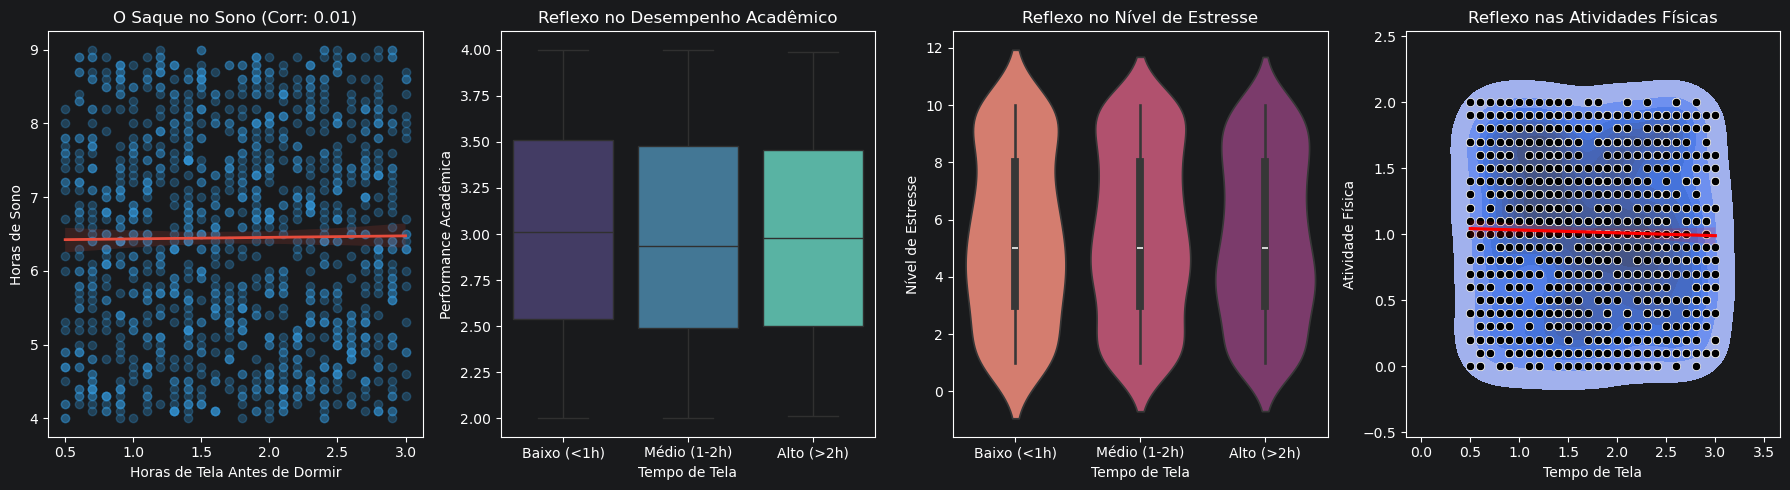

In [47]:
# Categorizando o tempo de tela antes de dormir para melhor visualização (Baixo <1h, Médio 1-2h, Alto >2h)\n",
df['screen_time_cat'] = pd.cut(df['screen_time_before_sleep'], bins=[0, 1, 2, 5],
                                   labels=['Baixo (<1h)', 'Médio (1-2h)', 'Alto (>2h)'])
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.regplot(x='screen_time_before_sleep', y='sleep_hours', data=df,
            scatter_kws={'alpha': 0.3, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2}, ax=axes[0])
axes[0].set(title=f'O Saque no Sono (Corr: {corl_sleep:.2f})', xlabel='Horas de Tela Antes de Dormir',
            ylabel='Horas de Sono')

sns.boxplot(x='screen_time_cat', y='academic_performance', data=df, palette='mako', ax=axes[1])
axes[1].set(title='Reflexo no Desempenho Acadêmico', xlabel='Tempo de Tela', ylabel='Performance Acadêmica')

sns.violinplot(x='screen_time_cat', y='stress_level', data=df, palette='flare', ax=axes[2])
axes[2].set(title='Reflexo no Nível de Estresse', xlabel='Tempo de Tela', ylabel='Nível de Estresse')

sns.kdeplot(x='screen_time_before_sleep', y='physical_activity', data=df, fill=True, ax=axes[3])
sns.scatterplot(x='screen_time_before_sleep', y='physical_activity', data=df, color='black', ax=axes[3])
sns.regplot(x='screen_time_before_sleep', y='physical_activity', data=df, scatter=False, color='red')
axes[3].set(title='Reflexo nas Atividades Físicas', xlabel='Tempo de Tela', ylabel='Atividade Física')

plt.tight_layout()
plt.show()

Novamente, não há uma correlação forte suficiente entre o tempo de tela antes de dormir com qualidade do sono e não afeta significativamente no dia seguinte

## TERCEIRA PERGUNTA
- Adolescentes com maior taxa de `physical_activity` apresentam níveis significativamente menores de estresse ou ansiedade, mesmo mantendo alto uso de redes sociais?


In [48]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,screen_time_cat
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,Alto (>2h)
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,Alto (>2h)
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,Baixo (<1h)
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,Médio (1-2h)
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,Alto (>2h)


Adolescentes com > 7h de tela: 184
Correlação Atividade Física vs Estresse (Grupo de Alto Risco): -0.01
Correlação Atividade Física vs Ansiedade (Grupo de Alto Risco): -0.10


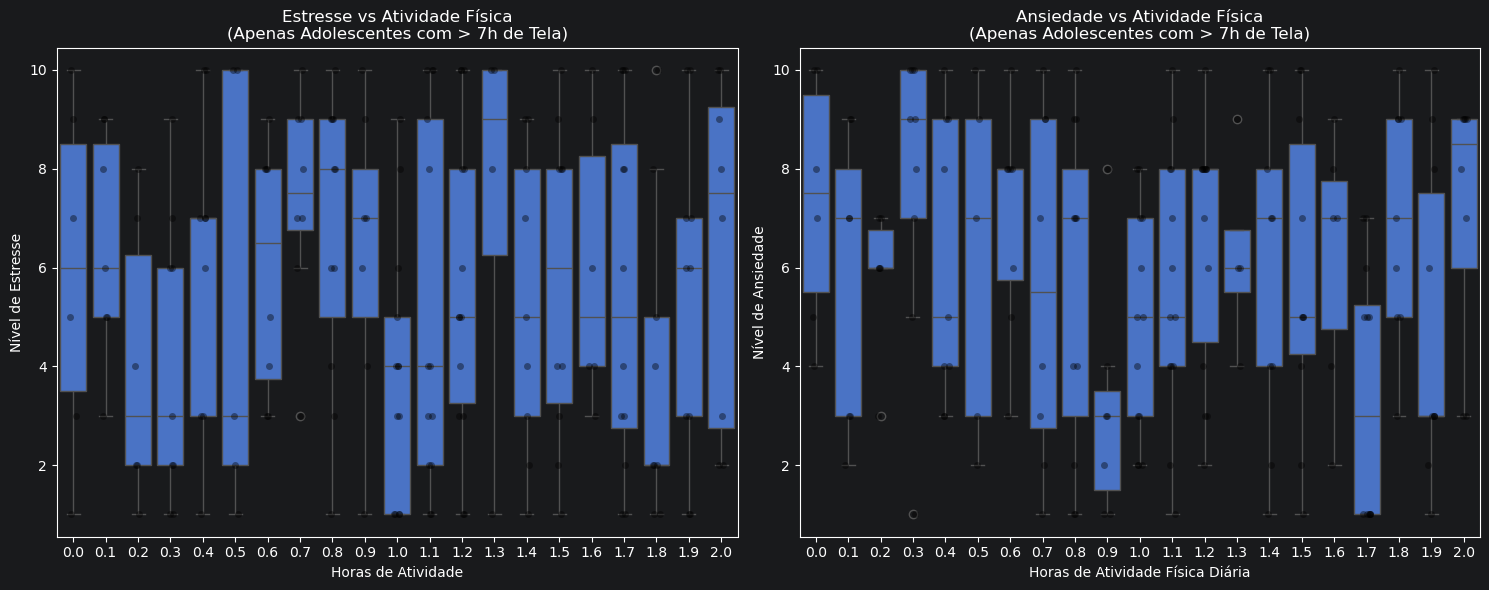

In [49]:
#Isolar o grupo de Alto uso de Redes Sociais
daily_social_df = df[df['daily_social_media_hours'] > 7].copy()

corr_stress = daily_social_df['physical_activity'].corr(daily_social_df['stress_level'])
corr_anxiety = daily_social_df['physical_activity'].corr(daily_social_df['anxiety_level'])

print(f"Adolescentes com > 7h de tela: {len(daily_social_df)}")
print(f"Correlação Atividade Física vs Estresse (Grupo de Alto Risco): {corr_stress:.2f}")
print(f"Correlação Atividade Física vs Ansiedade (Grupo de Alto Risco): {corr_anxiety:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Estresse
sns.boxplot(x='physical_activity', y='stress_level', data=daily_social_df, ax=axes[0])
sns.stripplot(x='physical_activity', y='stress_level', data=daily_social_df, color='black', alpha=0.4, ax=axes[0])
axes[0].set(title=f'Estresse vs Atividade Física\n(Apenas Adolescentes com > 7h de Tela)', xlabel='Horas de Atividade',
            ylabel='Nível de Estresse')

#Ansiedade
sns.boxplot(x='physical_activity', y='anxiety_level', data=daily_social_df, ax=axes[1])
sns.stripplot(x='physical_activity', y='anxiety_level', data=daily_social_df, color='black', alpha=0.4, ax=axes[1])
axes[1].set(title=f'Ansiedade vs Atividade Física\n(Apenas Adolescentes com > 7h de Tela)',
            xlabel='Horas de Atividade Física Diária', ylabel='Nível de Ansiedade')

plt.tight_layout()
plt.show()

Não. A atividade física não age como um escudo significativo contra o estresse ou a ansiedade para o grupo que já consome muita rede social

## QUARTA PERGUNTA
- A plataforma utilizada (`platform_usage`, como TikTok vs Instagram) isola comportamentos específicos? O impacto no `academic_performance` muda de acordo com a rede escolhida?


In [50]:
platform_stats = df.groupby('platform_usage')[
    ['daily_social_media_hours', 'stress_level', 'academic_performance', 'sleep_hours']].mean().round(2)
print("Média de Comportamento por Plataforma:")
print(platform_stats.to_markdown())

Média de Comportamento por Plataforma:
| platform_usage   |   daily_social_media_hours |   stress_level |   academic_performance |   sleep_hours |
|:-----------------|---------------------------:|---------------:|-----------------------:|--------------:|
| Both             |                       4.52 |           5.55 |                   2.98 |          6.46 |
| Instagram        |                       4.56 |           5.5  |                   3    |          6.44 |
| TikTok           |                       4.53 |           5.29 |                   3    |          6.45 |


<Figure size 1000x600 with 0 Axes>

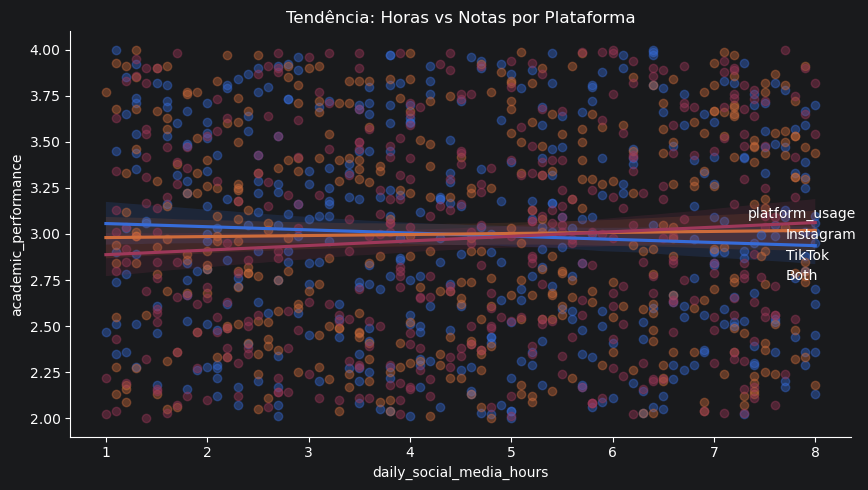

In [82]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='daily_social_media_hours', y='academic_performance', hue='platform_usage', data=df,
           aspect=1.5, height=5, scatter_kws={'alpha': 0.4})
plt.title('Tendência: Horas vs Notas por Plataforma')

plt.tight_layout()
plt.show()

Independente da plataforma, nos mostra que não afeta os resultados e continua irrelevante

## Construindo o Modelo

In [57]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']
X_encoded = pd.get_dummies(X, drop_first=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Árvore de Decisão

In [59]:
#class_weight='balanced' obriga o modelo a prestar atenção nos 2.5% de casos positivos
tree = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5)

# Roda os 5 folds e retorna a probabilidade de cada amostra
# quando ela estava FORA do treino (out-of-fold)
y_proba_tree = cross_val_predict(tree, X_encoded, y, cv=cv, method='predict_proba')[:, 1]

# Threshold tuning — maximiza F1 da classe positiva
prec, rec, thresholds = precision_recall_curve(y, y_proba_tree)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_t_tree = thresholds[f1s[:-1].argmax()]
y_pred_tree = (y_proba_tree >= best_t_tree).astype(int)

print("=== Árvore de Decisão ===")
print(f"AUC-ROC:           {roc_auc_score(y, y_proba_tree):.4f}")
print(f"Average Precision: {average_precision_score(y, y_proba_tree):.4f}")
print(f"Threshold usado:   {best_t_tree:.3f}\n")
print(classification_report(y, y_pred_tree, target_names=['Saudável', 'Depressão']))

=== Árvore de Decisão ===
AUC-ROC:           0.9677
Average Precision: 0.9372
Threshold usado:   1.000

              precision    recall  f1-score   support

    Saudável       1.00      1.00      1.00      1169
   Depressão       1.00      0.94      0.97        31

    accuracy                           1.00      1200
   macro avg       1.00      0.97      0.98      1200
weighted avg       1.00      1.00      1.00      1200



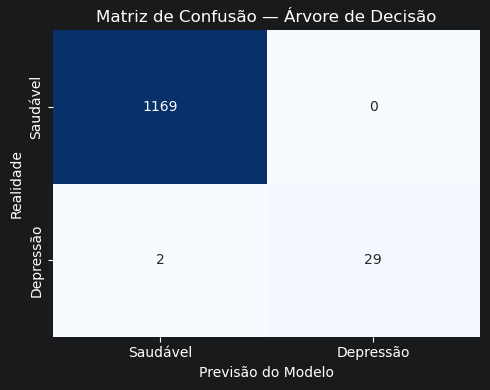

In [60]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, y_pred_tree), annot=True, fmt='d',
            cmap='Blues', cbar=False,
            xticklabels=['Saudável', 'Depressão'],
            yticklabels=['Saudável', 'Depressão'])
plt.title('Matriz de Confusão — Árvore de Decisão')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

In [64]:
tree.fit(X_encoded, y)

importancias_tree = pd.DataFrame({
    'Hábito': X_encoded.columns,
    'Importancia': tree.feature_importances_
}).sort_values(by='Importancia', ascending=False)

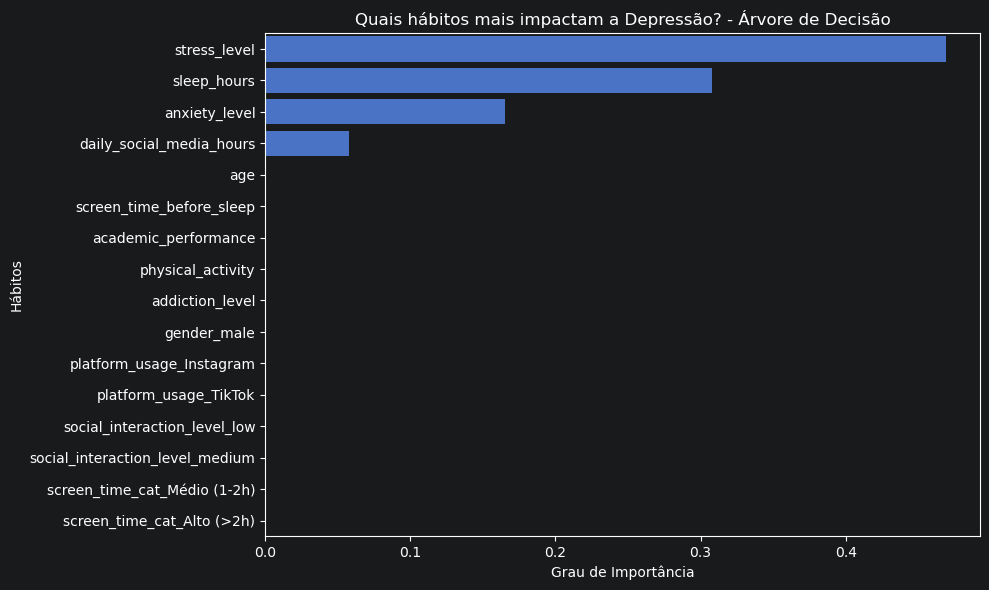

In [80]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Hábito', data=importancias)
plt.title('Quais hábitos mais impactam a Depressão? - Árvore de Decisão')
plt.xlabel('Grau de Importância')
plt.ylabel('Hábitos')
plt.tight_layout()
plt.show()

Para prever a saúde mental nesta base, as colunas a partir de `age` são apenas "barulhos".

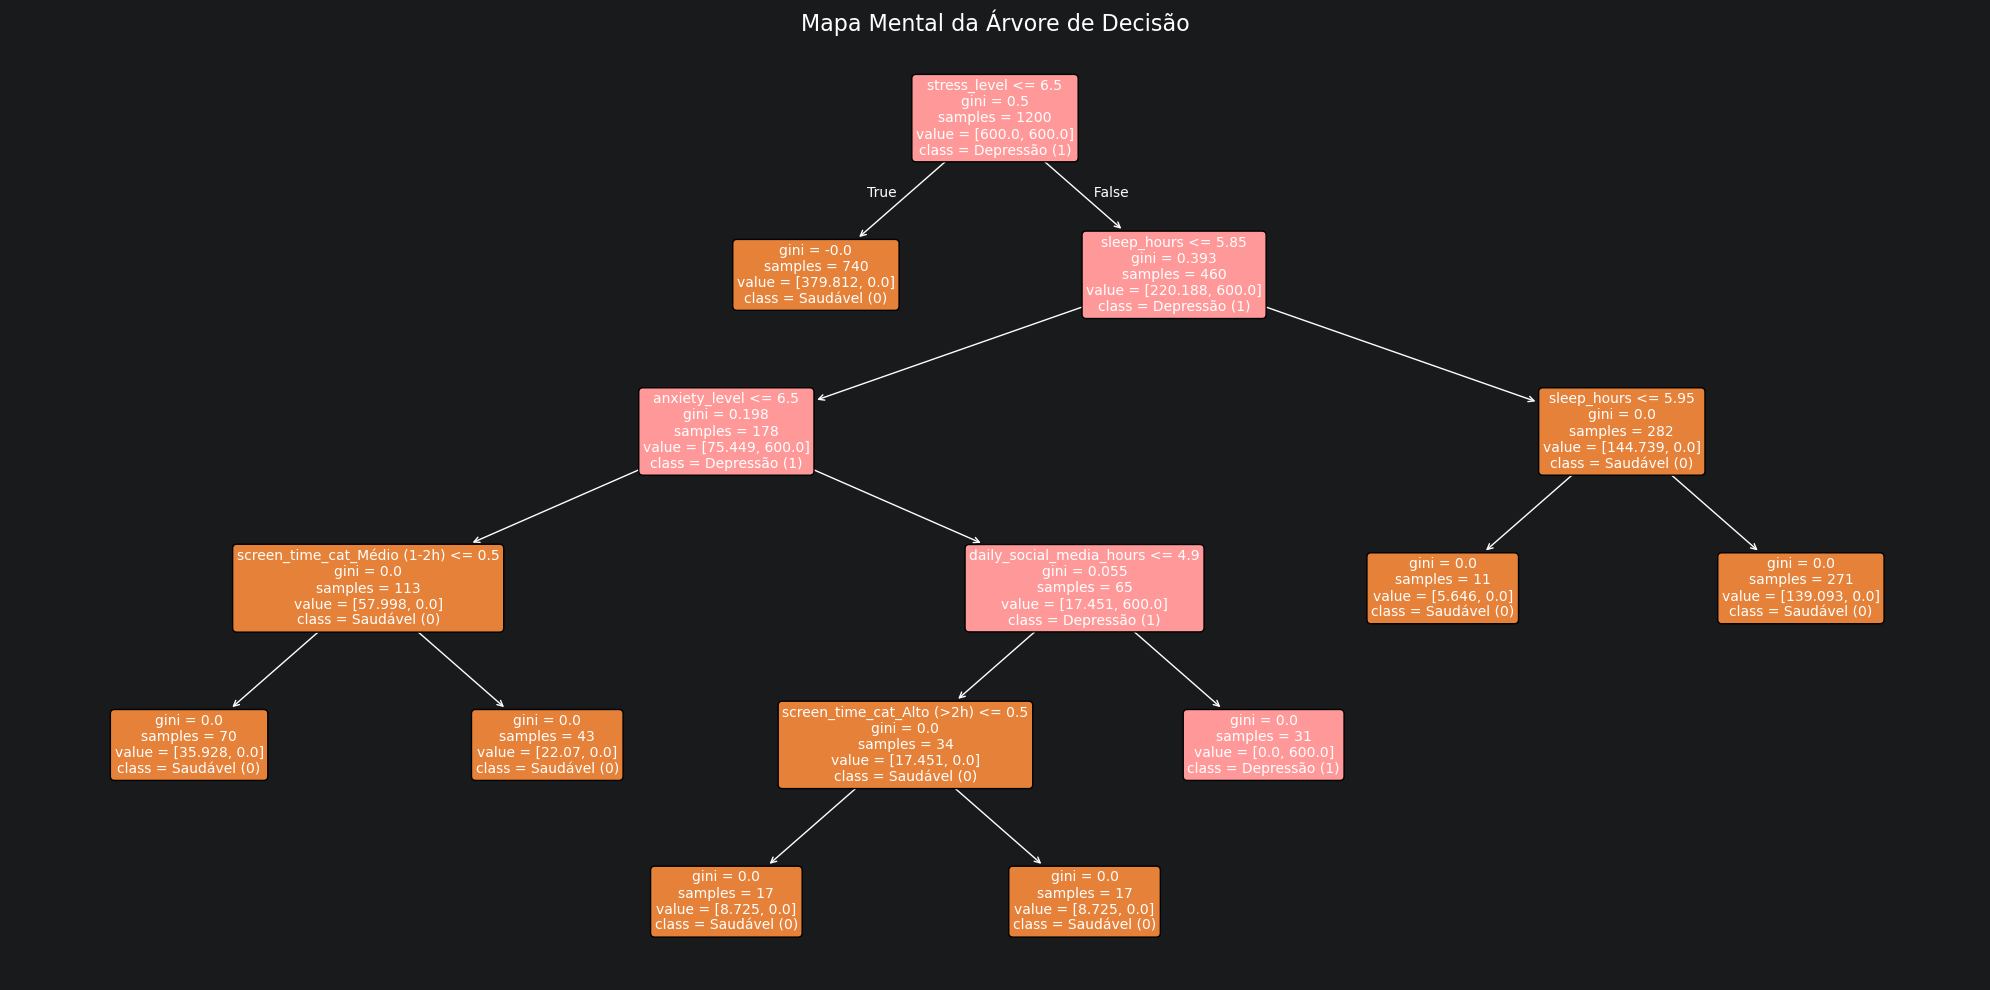

In [66]:
plt.figure(figsize=(20, 10))
caixas = plot_tree(tree,
          feature_names=X_train.columns,
          class_names=['Saudável (0)', 'Depressão (1)'],
          filled=True,
          rounded=True,
          fontsize=10)

for caixa in caixas:
    # Pega o texto escrito dentro da caixinha
    texto_da_caixa = caixa.get_text()

    # Pega o objeto gráfico (o fundo da caixa)
    caixa_grafica = caixa.get_bbox_patch()

    # Aplica a cor baseada na classe dominante
    if 'Depressão (1)' in texto_da_caixa:
        caixa_grafica.set_facecolor('#ff9999') # Vermelho pastel (Hex code)

plt.title('Mapa Mental da Árvore de Decisão', fontsize=16)
plt.tight_layout()
plt.show()

### Random Forest

In [74]:
#class_weight='balanced' obriga o modelo a prestar atenção nos 2.5% de casos positivos
#max_depth=5 evita que o modelo decore a base (overfitting)
rf = ImbPipeline([ ('smote', SMOTE(random_state=42, k_neighbors=3)), ('rf', RandomForestClassifier(n_estimators=200, random_state=42,class_weight='balanced',max_depth=5)) ])
#r_tree = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=5)

y_proba_rf = cross_val_predict(
    rf, X_encoded, y,
    cv=cv,
    method='predict_proba'
)[:, 1]

prec, rec, thresholds = precision_recall_curve(y, y_proba_rf)
f1s = 2*prec*rec/(prec+rec+1e-9)
best_t = thresholds[f1s[:-1].argmax()]
y_pred = (y_proba_rf >= best_t).astype(int)

In [75]:
print("=== Random Forest ===")
print(f"AUC-ROC:           {roc_auc_score(y, y_proba_rf):.4f}")
print(f"Average Precision: {average_precision_score(y, y_proba_rf):.4f}")
print(f"Threshold usado:   {best_t:.3f}\n")
print(classification_report(y, y_pred, target_names=['Saudável', 'Depressão']))

=== Random Forest ===
AUC-ROC:           0.9936
Average Precision: 0.9494
Threshold usado:   0.448

              precision    recall  f1-score   support

    Saudável       1.00      1.00      1.00      1169
   Depressão       1.00      0.94      0.97        31

    accuracy                           1.00      1200
   macro avg       1.00      0.97      0.98      1200
weighted avg       1.00      1.00      1.00      1200



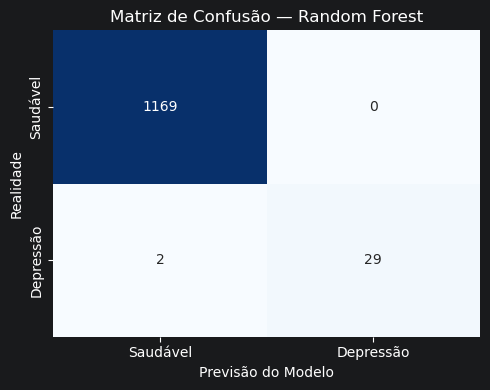

In [77]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d',
            cmap='Blues', cbar=False,
            xticklabels=['Saudável', 'Depressão'],
            yticklabels=['Saudável', 'Depressão'])
plt.title('Matriz de Confusão — Random Forest')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

In [78]:
rf.fit(X_encoded, y)

importancias_rf = pd.DataFrame({
    'Hábito': X_encoded.columns,
    'Importancia': rf.named_steps['rf'].feature_importances_
}).sort_values(by='Importancia', ascending=False)

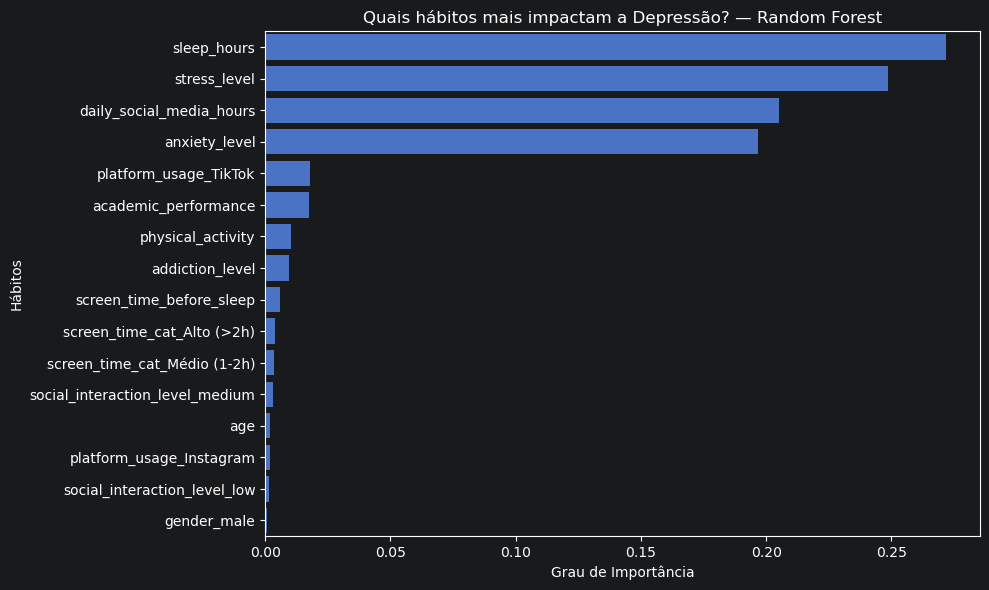

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Hábito', data=importancias_rf)
plt.title('Quais hábitos mais impactam a Depressão? — Random Forest')
plt.xlabel('Grau de Importância')
plt.ylabel('Hábitos')
plt.tight_layout()
plt.show()

Concluimos que o resultado é estatisticamente impossível quando se trata de dados de saúde, pois comportamento humano tem diversos ruidos. Provavelmente esse dataset é sintético, devido a Random Forest procurar por formulas matematicas e provavelmente ele achou a que foi usada nesse dataset.